# Spotify Track Popularity & Streaming Trends Analysis
##### Exploring how track characteristics and streaming-era trends influence music popularity.

## Goal
The goal of this project is to analyze Spotify track data to identify key factors associated with track popularity, including release type, track duration, and streaming-era trends, and to derive insights into how music consumption patterns have evolved.

## Tools
##### This project was conducted using Python and key data science libraries:
- Pandas – data cleaning and manipulation
- NumPy – numerical analysis
- Matplotlib & Seaborn – data visualization
- SciPy – statistical testing (t-test)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import ttest_ind

plt.rcParams['figure.figsize'] = (10, 6)

## Data Wrangling & Cleaning

#### Load the data

In [2]:
df = pd.read_csv('spotify_data clean.csv')

#### Look at the data

In [3]:
df.head()

,track_id,track_name,track_number,track_popularity,explicit,artist_name,artist_popularity,artist_followers,artist_genres,album_id,album_name,album_release_date,album_total_tracks,album_type,track_duration_min
0,3EJS5LyekDim1Tf5rBFmZl,Trippy Mane (ft. Project Pat),4,0,True,Diplo,77,2812821,moombahton,5QRFnGnBeMGePBKF2xTz5z,"d00mscrvll, Vol. 1",2025-10-31,9,album,1.55
1,1oQW6G2ZiwMuHqlPpP27DB,OMG!,1,0,True,Yelawolf,64,2363438,"country hip hop, southern hip hop",4SUmmwnv0xTjRcLdjczGg2,OMG!,2025-10-31,1,single,3.07
2,7mdkjzoIYlf1rx9EtBpGmU,Hard 2 Find,1,4,True,Riff Raff,48,193302,NaN,3E3zEAL8gUYWaLYB9L7gbp,Hard 2 Find,2025-10-31,1,single,2.55
3,67rW0Zl7oB3qEpD5YWWE5w,Still Get Like That (ft. Project Pat & Starrah),8,30,True,Diplo,77,2813710,moombahton,5QRFnGnBeMGePBKF2xTz5z,"d00mscrvll, Vol. 1",2025-10-31,9,album,1.69
4,15xptTfRBrjsppW0INUZjf,ride me like a harley,2,0,True,Rumelis,48,8682,dark r&b,06FDIpSHYmZAZoyuYtc7kd,come closer / ride me like a harley,2025-10-30,2,single,2.39


#### Check missing values and duplicates

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8582 entries, 0 to 8581
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   track_id            8582 non-null   object 
 1   track_name          8582 non-null   object 
 2   track_number        8582 non-null   int64  
 3   track_popularity    8582 non-null   int64  
 4   explicit            8582 non-null   bool   
 5   artist_name         8579 non-null   object 
 6   artist_popularity   8582 non-null   int64  
 7   artist_followers    8582 non-null   int64  
 8   artist_genres       5221 non-null   object 
 9   album_id            8582 non-null   object 
 10  album_name          8582 non-null   object 
 11  album_release_date  8582 non-null   object 
 12  album_total_tracks  8582 non-null   int64  
 13  album_type          8582 non-null   object 
 14  track_duration_min  8582 non-null   float64
dtypes: bool(1), float64(1), int64(5), object(8)
memory usag

In [5]:
# Check missing value percentages (descending)
missing_series = df.isnull().mean() * 100
print(missing_series.sort_values(ascending=False))

artist_genres         39.163365
artist_name            0.034957
track_name             0.000000
track_number           0.000000
track_popularity       0.000000
explicit               0.000000
track_id               0.000000
artist_popularity      0.000000
artist_followers       0.000000
album_id               0.000000
album_name             0.000000
album_release_date     0.000000
album_total_tracks     0.000000
album_type             0.000000
track_duration_min     0.000000
dtype: float64


-  There are some missing values in artist_name and artist_genres. Let's handle these values.

In [6]:
# Check for duplicates
print(df.duplicated().sum())

0


- This confirms that every record in the dataset is unique, and there is no redundancy that could bias the analysis.

#### Handle Missing Values and Inspect Data

##### Handling missing values in artist_genres: Replaced missing genres with 'Unknown'.

In [7]:
df['artist_genres'] = df['artist_genres'].fillna('Unknown')

##### Check null values in artist_name

In [8]:
df[df['artist_name'].isnull()]

,track_id,track_name,track_number,track_popularity,explicit,artist_name,artist_popularity,artist_followers,artist_genres,album_id,album_name,album_release_date,album_total_tracks,album_type,track_duration_min
1807,2NbsBSshscKIPRG3kwBbfo,Never Felt So Alone,1,68,False,NaN,0,0,Unknown,33JqWTchq6piiQddrRIvJX,Never Felt So Alone,2023-04-07,1,single,2.66
6517,3QhfFRPkhPCR1RMJWV1gde,Radio,8,65,True,NaN,0,0,Unknown,0Dt3FbpMQwjoT5KNAw0IXR,Born To Die – Paradise Edition (Special Version),2012-01-01,24,album,3.57
6679,5EhZC8GFOVXrpiUW22jncE,Urban Twilight,4,30,False,NaN,0,0,Unknown,1Cog6aZ6NwnJiuINc0LQEU,Darkbloom,2011-04-18,5,single,4.26


-  Refined missing 'artist_name' data by performing manual lookup and imputation. Although these records were few, their high popularity scores (68, 70) indicated they were significant data points. To prevent the loss of meaningful streaming insights, I identified the correct artists and updated the entries.

##### Fill in the null artist_name

In [9]:
df.loc[1807, 'artist_name'] = 'Labrinth'
df.loc[6517, 'artist_name'] = 'Lana Del Rey'
df.loc[6679, 'artist_name'] = 'Grimes'

- Missing artist names were manually verified using Spotify search.

##### Date Transformation & Data Inspection

In [10]:
# Extract 'year' from album_release_date for annual trend analysis.
df['album_release_date'] = pd.to_datetime(df['album_release_date'])
df['release_year'] = df['album_release_date'].dt.year

# Verify the final dataset for consistency.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8582 entries, 0 to 8581
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   track_id            8582 non-null   object        
 1   track_name          8582 non-null   object        
 2   track_number        8582 non-null   int64         
 3   track_popularity    8582 non-null   int64         
 4   explicit            8582 non-null   bool          
 5   artist_name         8582 non-null   object        
 6   artist_popularity   8582 non-null   int64         
 7   artist_followers    8582 non-null   int64         
 8   artist_genres       8582 non-null   object        
 9   album_id            8582 non-null   object        
 10  album_name          8582 non-null   object        
 11  album_release_date  8582 non-null   datetime64[ns]
 12  album_total_tracks  8582 non-null   int64         
 13  album_type          8582 non-null   object      

##### Defining the Analysis Scope

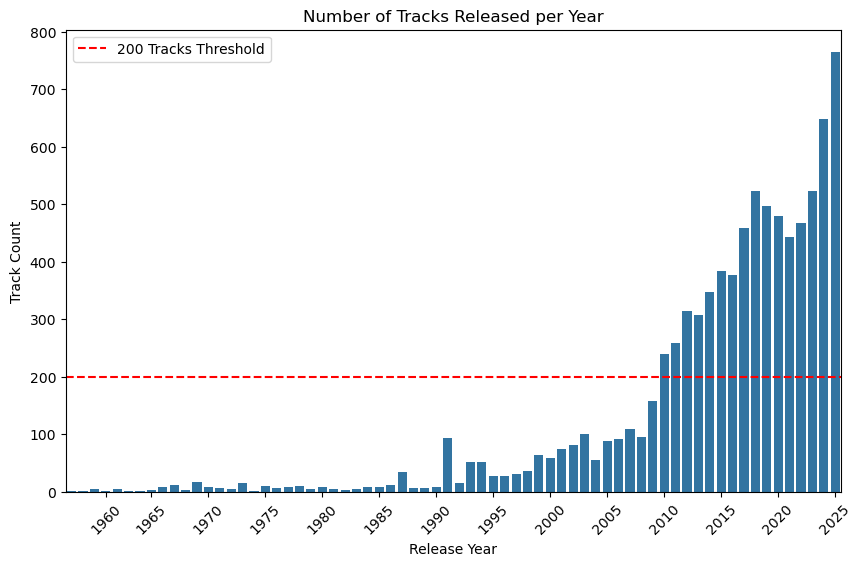

In [11]:
# Count the number of tracks released each year
year_counts = df['release_year'].value_counts().sort_index()

# Create a bar plot to visualize yearly track distribution
sns.barplot(x=year_counts.index, y=year_counts.values)

# Add a horizontal reference line at 200 tracks to highlight the minimum sample size threshold
plt.axhline(y=200, color='red', linestyle='--', linewidth=1.5, label='200 Tracks Threshold')

# Display x-axis labels every 5 years to improve readability and reduce clutter
tick_years = [year for year in year_counts.index if year % 5 == 0]
tick_positions = [list(year_counts.index).index(year) for year in tick_years]

plt.xticks(ticks=tick_positions, labels=tick_years, rotation=45)
plt.title('Number of Tracks Released per Year')
plt.xlabel('Release Year')
plt.ylabel('Track Count')
plt.legend()
plt.show()

- To ensure meaningful comparisons, the dataset was restricted to tracks released from 2010 onward, aligning with the rise of modern music streaming platforms.
- Track counts increase substantially after 2010, with yearly observations consistently exceeding 200 tracks. Restricting the analysis to this period helps reduce bias caused by differences in music consumption and popularity measurement across decades, while also ensuring a sufficient and consistent sample size for analysis.

In [12]:
# Filter for modern streaming era (2010-post)
df = df[df['release_year'] >= 2010]
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7031 entries, 0 to 7030
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   track_id            7031 non-null   object        
 1   track_name          7031 non-null   object        
 2   track_number        7031 non-null   int64         
 3   track_popularity    7031 non-null   int64         
 4   explicit            7031 non-null   bool          
 5   artist_name         7031 non-null   object        
 6   artist_popularity   7031 non-null   int64         
 7   artist_followers    7031 non-null   int64         
 8   artist_genres       7031 non-null   object        
 9   album_id            7031 non-null   object        
 10  album_name          7031 non-null   object        
 11  album_release_date  7031 non-null   datetime64[ns]
 12  album_total_tracks  7031 non-null   int64         
 13  album_type          7031 non-null   object        
 1

## Exploratory Data Analysis (EDA): Understanding Modern Music Popularity Patterns
* Although artist genre is typically a key factor in music popularity analysis, the high proportion of missing or unknown values in this dataset limits its analytical reliability. Therefore, artist genre was excluded from the main analysis to avoid biased interpretations.

### PART 1 — Popularity Distribution & Hit Definition

To ensure an objective and rigorous analysis, I first examine the descriptive statistics for key metrics: Track Popularity, Artist Followers, and Artist Popularity.

In [13]:
stats_summary = pd.concat([df['track_popularity'].describe(), df['artist_followers'].describe(), df['artist_popularity'].describe()], axis=1)

stats_summary.columns = ['Track Popularity', 'Artist Followers', 'Artist Popularity']

pd.options.display.float_format = '{:,.2f}'.format

display(stats_summary)

,Track Popularity,Artist Followers,Artist Popularity
count,"7,031.00","7,031.00","7,031.00"
mean,52.09,"26,600,507.93",69.74
std,23.80,"40,569,411.89",20.66
min,0.00,0.00,0.00
25%,39.00,"344,334.00",59.00
50%,58.00,"6,429,788.00",75.00
75%,70.00,"35,576,126.00",85.00
max,99.00,"145,542,136.00",100.00


#### PART 1 Key Insights (Classification Framework)

To establish a consistent analytical framework, percentile-based thresholds were used instead of arbitrary cut-off values.

Hit Tracks:
- Tracks with popularity scores above the 75th percentile (Track Popularity ≥ 70) were classified as hit tracks, representing the top-performing segment of the dataset.

Viral Hits:
- Tracks with hit-level popularity (Track Popularity ≥ 70) despite artist follower counts below the 25th percentile (Artist Followers < 344,334) were interpreted as potential viral breakout tracks.

Established Hits:
- Tracks with hit-level popularity (Track Popularity ≥ 70) and artist follower counts above the 75th percentile (Artist Followers > 35,576,126) were categorized as established hits, reflecting success supported by large existing audience reach.

These classifications provide a structured foundation for analyzing how artist reach, release strategies, and streaming-era listening trends relate to track success.

### PART 2 - Core Relationships Between Artist Reach and Track Popularity
This section applies the classification framework established in Part 1 to examine how artist reach, popularity, and release formats relate to track success and potential viral breakout behavior.

#### 2.1. Correlation Overview

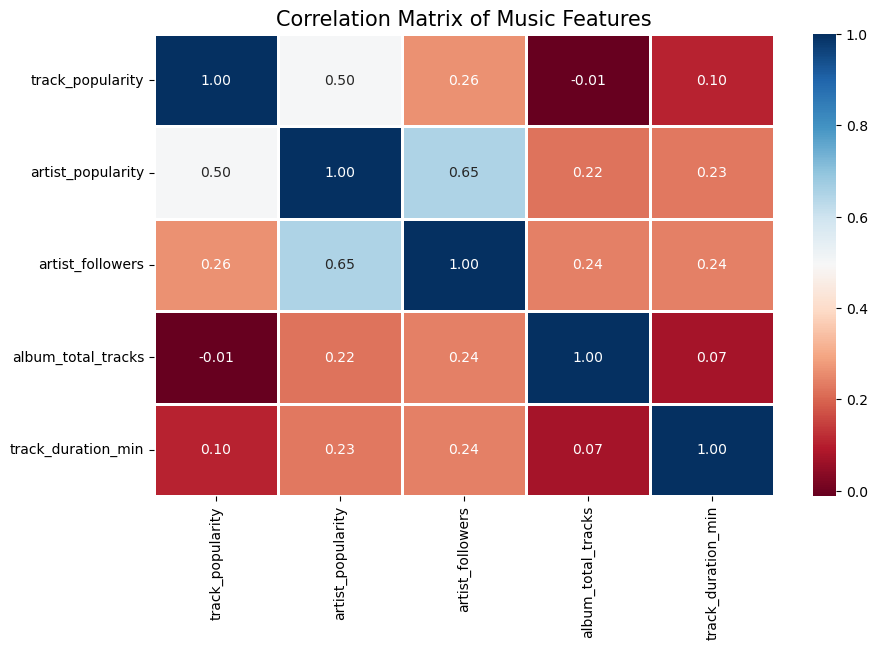

In [14]:
cols_to_corr = ['track_popularity', 'artist_popularity', 'artist_followers', 'album_total_tracks', 'track_duration_min']
corr_matrix = df[cols_to_corr].corr()

sns.heatmap(corr_matrix, annot=True, cmap='RdBu', fmt=".2f", linewidths=1)
plt.title('Correlation Matrix of Music Features', fontsize=15)
plt.show()

- The results suggest that track popularity is more strongly associated with artist-level attributes than with album-level characteristics. In particular, the moderate correlation between track popularity and artist popularity (0.50) highlights a meaningful relationship, while the weaker correlation with artist followers (0.26) suggests a more limited but still relevant association, especially when considered alongside group-level differences.

#### 2. Artist Reach vs Track Popularity

In [15]:
result = df.groupby(np.where(df['track_popularity'] >= 70, "Hit Tracks (≥ 70)", "Non-Hit Tracks (< 70)"))[['artist_popularity', 'artist_followers']].agg(['mean', 'median'])
result

artist_popularity        artist_followers              
                                   mean median             mean        median
Hit Tracks (≥ 70)                 81.30  82.00    38,488,753.44 18,700,851.00
Non-Hit Tracks (< 70)             65.50  69.00    22,245,796.93  3,007,142.00

- The analysis shows that hit tracks are generally associated with artists who have higher popularity scores and substantially larger follower bases.
- While the correlation between artist followers and track popularity is relatively weak (0.26), group-level comparisons reveal that hit tracks tend to come from artists with significantly higher average follower counts and popularity scores.
- The large gap between mean and median follower counts also suggests a heavily right-skewed distribution, where a small number of extremely popular artists contribute disproportionately high follower counts.
- Overall, the results indicate that artist popularity and followers are associated with track popularity, although this analysis does not establish a causal relationship.

#### 2.3 Hit Distribution Across Artist Fandom Size

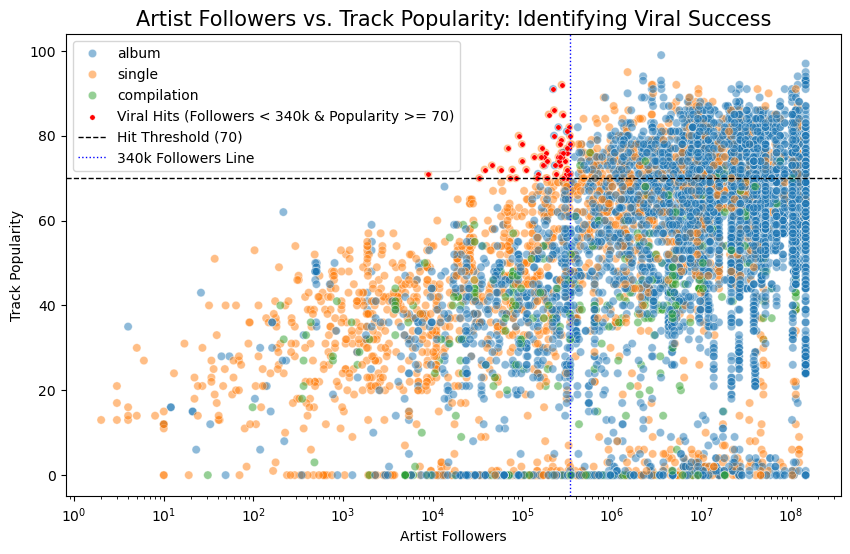

Total Hits: 1885.      Total Viral Hits: 60.      Total Established Hits: 674.


In [16]:
# 1. Create a scatter plot to visualize the relationship
sns.scatterplot(data=df, x='artist_followers', y='track_popularity', alpha=0.5, hue='album_type')

# 2. Highlight the 'Viral Hits' region (Low followers & High popularity)
# Defined as tracks with high popularity (>= 70) from artists in the lower 75% of follower counts (344,334)
viral_hits = df[(df['artist_followers'] < 344334) & (df['track_popularity'] >= 70)]
sns.scatterplot(data=viral_hits, x='artist_followers', y='track_popularity', 
                color='red', s=15, label='Viral Hits (Followers < 340k & Popularity >= 70)')

# Tracks with high fandom power (High followers & High popularity)
# Defined as tracks with high popularity (>= 70) from artists in the top 25% of follower counts (>= 35,576,126)
established_hits = df[(df['artist_followers'] >= 35576126) & (df['track_popularity'] >= 70)]

# 3. Apply log scale and add threshold guidelines for better interpretation
plt.xscale('log')
plt.axhline(70, color='black', linestyle='--', linewidth=1, label='Hit Threshold (70)')
plt.axvline(344334, color='blue', linestyle=':', linewidth=1, label='340k Followers Line')

plt.title('Artist Followers vs. Track Popularity: Identifying Viral Success', fontsize=15)
plt.xlabel('Artist Followers')
plt.ylabel('Track Popularity')
plt.legend()
plt.show()

# Print the count of tracks categorized by success type
print(f"Total Hits: {(df['track_popularity'] >= 70).sum()}.      Total Viral Hits: {len(viral_hits)}.      Total Established Hits: {len(established_hits)}.")

- Out of 1,885 total hit tracks, 674 were associated with artists above the 75th percentile in follower count, suggesting that established audience reach may contribute substantially to track success.

- At the same time, 60 hit tracks were identified from artists below the 25th percentile in follower count. These potential viral breakout tracks indicate that high popularity is not exclusively limited to artists with large existing audiences, and may also be influenced by viral exposure or platform-driven discovery mechanisms.

#### 2.4 Artist Popularity vs. Track Success and Viral Breakout Patterns Across Album Types

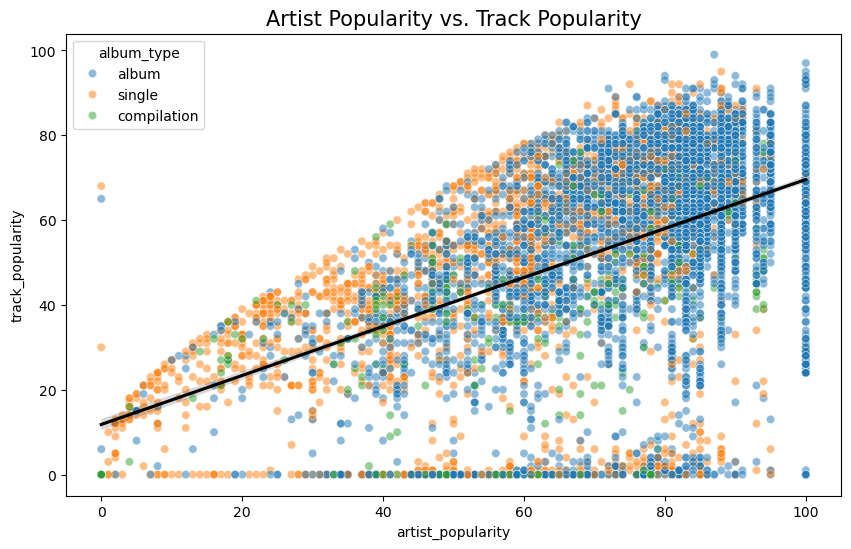

In [17]:
sns.scatterplot(data=df, x='artist_popularity', y='track_popularity', alpha=0.5, hue='album_type')
sns.regplot(data=df, x='artist_popularity', y='track_popularity', scatter=False, color='black')
plt.title('Artist Popularity vs. Track Popularity', fontsize=15)
plt.show()

- A strong positive relationship is observed between artist popularity and track popularity.
- However, the relationship is not deterministic. While less popular artists rarely produce hit tracks, highly popular artists exhibit a wide range of outcomes, from low-performing tracks to major hits.
- Despite this strong association, the direction of the relationship remains unclear — it is uncertain whether more popular artists drive track success, or whether successful tracks increase artist popularity.
- To better understand causality, future analysis would require temporal data, such as artist popularity before a track’s release and how it evolves after the track gains traction.
- The data reveals that Albums (Blue) remain the primary format for top-tier hits, dominating the high-popularity range. In contrast, Singles (Orange) show a unique "viral" trend, often achieving high track popularity even for emerging artists with lower overall popularity. Meanwhile, Compilations (Green) maintain a stable presence in the mid-range but rarely reach the extreme peaks seen in studio albums or singles.

#### PART 2 Key Insights
- Artist reach strongly influences track success, but audience size alone does not guarantee high-performing releases.

- While established artists account for a substantial share of hit tracks, the presence of viral breakout tracks suggests that platform-driven discovery and streaming-era exposure may also enable smaller artists to achieve mainstream success.

- Additionally, singles appear more closely associated with potential viral breakout behavior, whereas albums dominate the highest popularity ranges overall.

### PART 3 — Album Release Strategies and Popularity Trends

In [18]:
order = ['album', 'single', 'compilation']

album_summary = df.groupby('album_type')[['track_popularity', 'artist_popularity', 'artist_followers']].mean().reindex(order)

album_summary.style.format({'track_popularity': '{:.2f}', 'artist_popularity': '{:.2f}', 'artist_followers': '{:,.0f}'})

,track_popularity,artist_popularity,artist_followers
album_type,,,
album,55.80,75.51,"34,987,296"
single,46.53,58.94,"10,807,449"
compilation,36.51,60.81,"14,351,893"


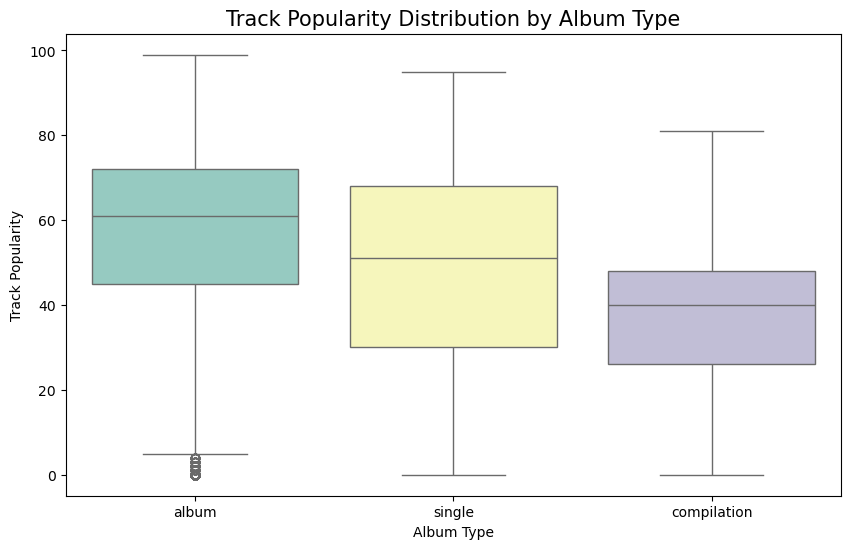

In [19]:
sns.boxplot(data=df, x='album_type', y='track_popularity', palette='Set3', hue='album_type', legend=False)
plt.title('Track Popularity Distribution by Album Type', fontsize=15)
plt.xlabel('Album Type')
plt.ylabel('Track Popularity')
plt.show()

- Albums are generally associated with established artists and more consistently high-performing tracks.
- Singles show more variability, suggesting a mix of emerging artists and potential breakout hits.
- Compilations tend to have lower track-level engagement compared to other release types.

#### PART 3 Key Insights
- This analysis highlights structural differences across release types, showing that album formats are associated with more established artists and higher engagement, while singles and compilations represent more variable and lower-performing segments of the music ecosystem.

### PART 4 — Streaming-Era Listening Trends: Are Songs Getting Shorter?
Building on the differences across release types, this section shifts the focus to temporal trends, examining how track duration has evolved in the streaming era.

#### 1. Yearly Average Track Duration

In [20]:
# release_date → year transition
df['release_year'] = pd.to_datetime(df['album_release_date']).dt.year

# yearly average duration
yearly_duration = df.groupby('release_year')['track_duration_min'].mean()

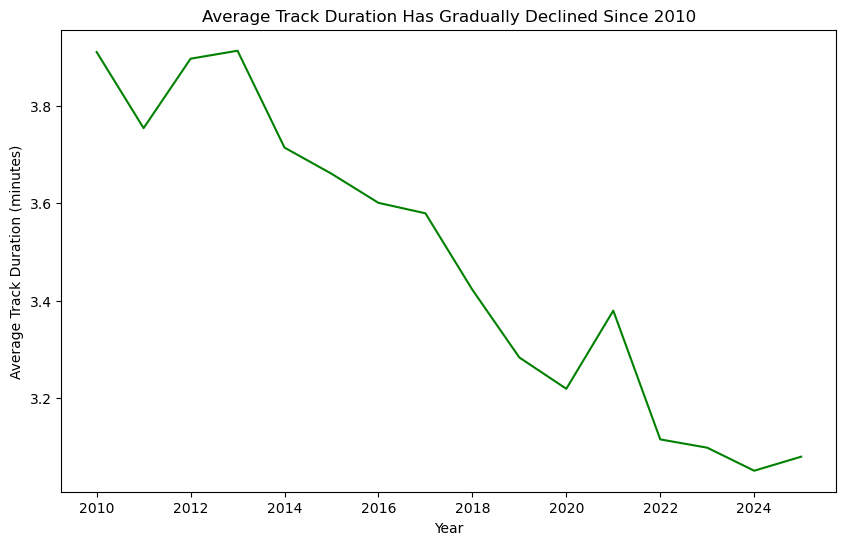

In [21]:
plt.plot(yearly_duration.index, yearly_duration.values, color='green')

plt.title('Average Track Duration Has Gradually Declined Since 2010')
plt.xlabel('Year')
plt.ylabel('Average Track Duration (minutes)')
plt.show()

- The plot shows a gradual decline in average track duration over time since 2010, indicating that songs have generally become shorter in recent years. \
  This suggests a shift toward more concise music consumption in the streaming era.

#### 2. Pre vs Post TikTok Era
To better interpret recent changes in music consumption, the year 2018 is used as an approximate breakpoint for the “TikTok era,” representing the period when short-form video platforms began to significantly influence music discovery and listening behavior. While not a strict cutoff, it serves as a practical proxy for the shift toward short-form content-driven engagement.

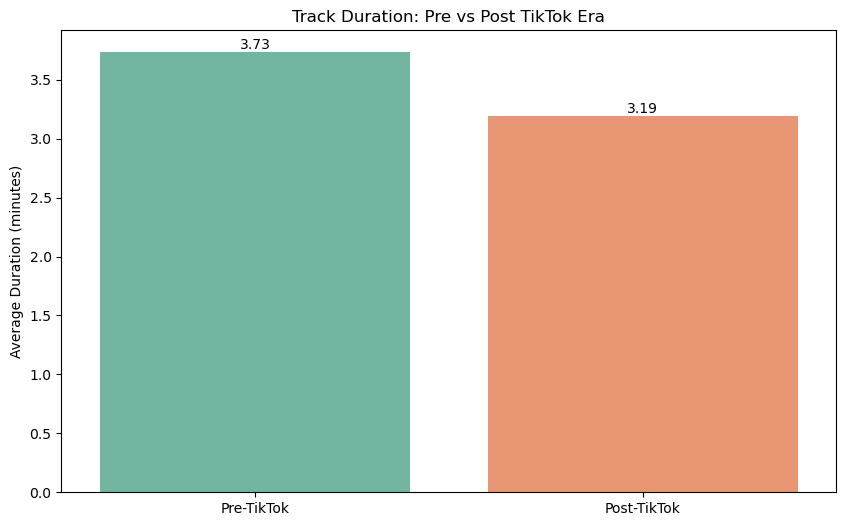

In [22]:
order = ['Pre-TikTok', 'Post-TikTok']
df['tiktok_era'] = df['release_year'].apply(lambda x: 'Pre-TikTok' if x < 2018 else 'Post-TikTok')
tiktok_compare = df.groupby('tiktok_era')['track_duration_min'].mean().reindex(order)

ax = sns.barplot(x=tiktok_compare.index, y=tiktok_compare.values, hue=tiktok_compare.index, palette='Set2', legend=False)

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')
    
plt.title('Track Duration: Pre vs Post TikTok Era')
plt.xlabel('')
plt.ylabel('Average Duration (minutes)')
plt.show()

- The results show that average track duration decreased from 3.71 minutes in the pre-TikTok period to 3.19 minutes in the post-TikTok period.
- This suggests a gradual shift toward shorter songs in the more recent era, potentially reflecting changes in listener behavior and the increasing influence of short-form content platforms on music consumption patterns.

#### PART 4 Key Insights
- Track duration has gradually decreased over time, with songs in the post-TikTok era averaging noticeably shorter lengths than those released earlier.
- This trend suggests a shift toward shorter and more concise music consumption patterns in the streaming era.

### PART 5 - Do Shorter Songs Perform Better?
Given the observed decrease in average track duration in the post-TikTok era, this section explores whether shorter songs are associated with higher popularity and better performance.

#### 1. Duration vs Popularity Relationship

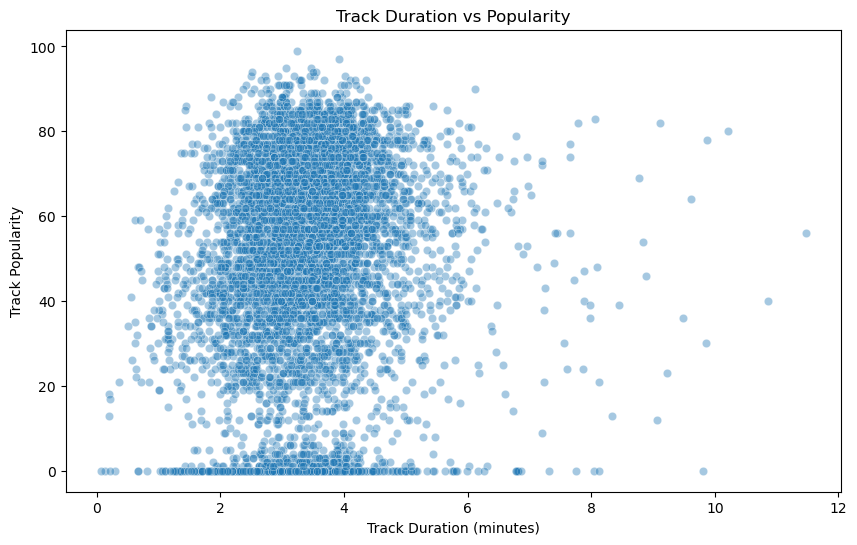

In [23]:
sns.scatterplot(data=df, x='track_duration_min', y='track_popularity', alpha=0.4)

plt.title('Track Duration vs Popularity')
plt.xlabel('Track Duration (minutes)')
plt.ylabel('Track Popularity')
plt.show()

- There is no significant linear correlation between track duration and popularity.
- However, a high density of data points is observed within the 2 to 4.5-minute range, reflecting the market's standard track length.
- Outside of this range, both extremely short and long tracks are relatively scarce and exhibit higher volatility in popularity.

#### 2. Short vs Long Songs

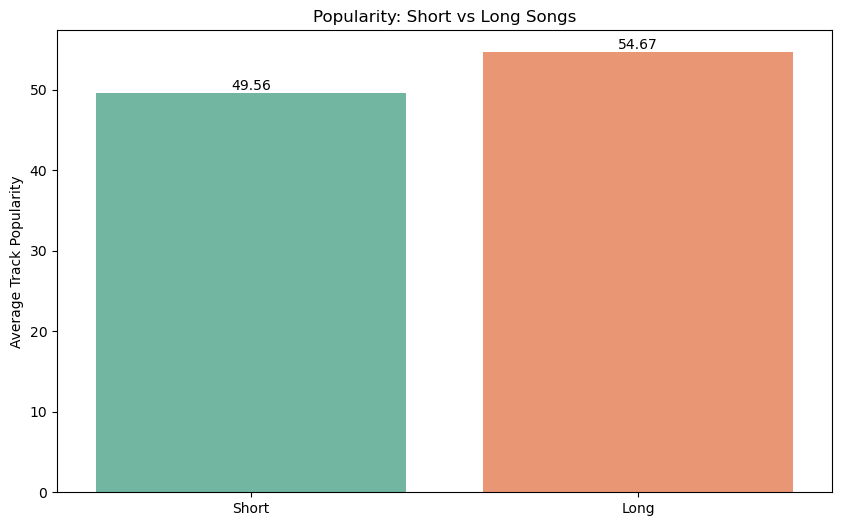

In [24]:
order = ['Short', 'Long']

df['duration_group'] = df['track_duration_min'].apply(lambda x: 'Short' if x <= df['track_duration_min'].median() else 'Long')

group_stats = df.groupby('duration_group')['track_popularity'].mean().reindex(order)

ax2 = sns.barplot(x=group_stats.index, y=group_stats.values, palette='Set2', hue=group_stats.index, legend=False)

for container in ax2.containers:
    ax2.bar_label(container, fmt='%.2f')

plt.title('Popularity: Short vs Long Songs')
plt.xlabel('')
plt.ylabel('Average Track Popularity')
plt.show()

- Longer tracks were associated with higher average popularity in this dataset.

In [25]:
short = df[df['duration_group'] == 'Short']['track_popularity']
long = df[df['duration_group'] == 'Long']['track_popularity']

t_stat, p_value = ttest_ind(short, long, equal_var=False)

print(f"T-statistic: {t_stat:.3f}")
print(f"P-value: {p_value:.20f}")

T-statistic: -9.055
P-value: 0.00000000000000000017


- The difference is statistically significant (t = -9.055, p < 0.05), suggesting a robust relationship between track duration and popularity.

#### PART 5 Key Insights
- Most tracks cluster between 2–4.5 minutes, while extreme durations are less common and more variable in popularity.
- This suggests that although track durations have decreased in the streaming era, shorter songs do not necessarily perform better in terms of popularity.

## Conclusion & Key Findings
- Artist influence plays a significant role in determining track success.
- However, high artist popularity does not guarantee a hit, indicating substantial variability in streaming performance across tracks.
- Contrary to the trend of shrinking track lengths in the streaming era, longer tracks maintained a statistically significant advantage in average popularity within this dataset.

## Business Implications
- The findings suggest that track performance may be increasingly shaped by playlist exposure, listener behavior, and recommendation systems rather than artist popularity alone.
- The growing prevalence of shorter tracks may reflect changing music production strategies and platform-driven incentives associated with streaming and short-form content platforms, even though longer tracks still hold a popularity advantage among listeners.

## Limitations & Future Work
- This analysis identifies correlations but cannot determine causality due to the absence of granular time-series streaming metrics (e.g., daily stream counts over time) and user-level behavioral data.
- Future work could incorporate time-series streaming data, playlist placement metrics, and Spotify audio features to better understand the drivers of track success.
- The high percentage of 'Unknown' genres (approx. 39%) poses a limitation for comprehensive genre-specific insights. Future work will involve fetching missing genre metadata via the Spotify Web API to improve data completeness and refine market segmentation analysis.